(examples:cbed_cvdms_comparison)=
# CBED: Fourier 多片层 vs CVDMS 对比

本 notebook 对比传统的 Fourier 多片层算法与 **CVDMS（耦合波动学多片层）** 算法在硅 (111) 晶带轴的 CBED 模拟结果。

## 环境配置


In [1]:
import abtem
import ase
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk
from abtem.multislice import CVDMSMultislice, FourierMultislice

abtem.config.set({
    "device": "gpu",
    "fft": "numpy",
    "diagnostics.task_progress": False,
});

## 原子模型

创建硅晶体 (111) 晶带轴。


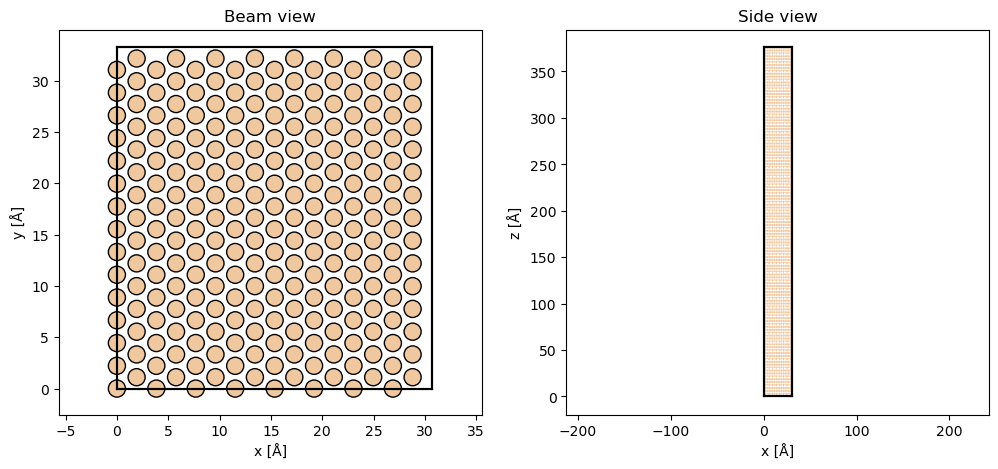

In [2]:
silicon = bulk("Si", crystalstructure="diamond")
silicon_111 = ase.build.surface(silicon, (1, 1, 1), layers=3, periodic=True)
silicon_111_orthogonal = abtem.orthogonalize_cell(silicon_111)

# 使用适中的尺寸以便对比运行
atoms = silicon_111_orthogonal * (8, 5, 40)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
abtem.show_atoms(atoms, ax=ax1, title="Beam view")
abtem.show_atoms(atoms, ax=ax2, plane="xz", title="Side view", linewidth=0.0);

## 势能

使用冻声子方法创建系综势能。


In [4]:
frozen_phonons = abtem.FrozenPhonons(atoms, 16, {"Si": 0.2})

potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,
    projection="finite",
    slice_thickness=1,
    exit_planes=40,
)

## 探针

创建 300 keV 探针，汇聚半角 9.4 mrad。


tasks:   0%|          | 0/2 [00:00<?, ?it/s]

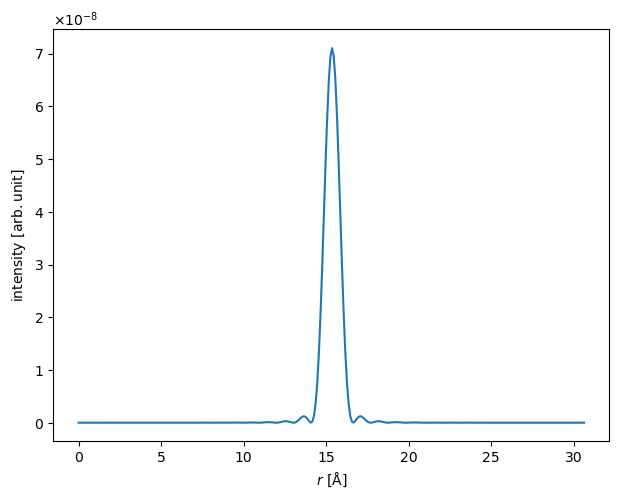

In [5]:
wave = abtem.Probe(energy=300e3, semiangle_cutoff=9.4)
wave.grid.match(potential)
wave.profiles().show();

## 1. Fourier 多片层 CBED

运行标准 Fourier 多片层算法。


In [6]:
print("Running Fourier multislice...")
measurements_fourier = wave.multislice(
    potential,
    algorithm=FourierMultislice(order=1),
).diffraction_patterns(max_angle="cutoff")

result_fourier = measurements_fourier.mean(0).compute()
print("Fourier multislice done.")

Running Fourier multislice...


tasks:   0%|          | 0/66 [00:00<?, ?it/s]

Fourier multislice done.


## 2. CVDMS 多片层 CBED

运行 CVDMS 算法。比较三个变体：

- **CVDMS (FD)** — 有限差分 Laplacian（9 点模板，`derivative_accuracy=8`），无背散射（默认）
- **CVDMS (FFT)** — FFT Laplacian（精确带限），无背散射（默认）
- **CVDMS (BSC)** — 有限差分 Laplacian 加 **BSC 前向波修正**（`backscattering=True`）。
  在每个切片界面，背散射损失从前向波中减去：
  `ψ_corrected = ψ_forward - BSC(ψ_forward)`。
  注意：这修正了前向波但**不**单独追踪背散射分量。
  （参见 `calculate_backscattered=True` 获取完整背散射波反向传播。）

In [ ]:
print("Running CVDMS multislice...")

# --- CVDMS (FD): 有限差分 Laplacian，无背散射 ---
algorithm_cvdms_fd = CVDMSMultislice(
    order=1,
    convergence_threshold=1e-6,
    max_terms=50,
    derivative_accuracy=8,       # 9-point stencil（对应 C++ 九点法）
    laplace_method="finite-difference",
)

measurements_cvdms_fd = wave.multislice(
    potential,
    algorithm=algorithm_cvdms_fd,
).diffraction_patterns(max_angle="cutoff")
result_cvdms_fd = measurements_cvdms_fd.mean(0).compute()
print("CVDMS (FD) done.")

# --- CVDMS (BSC): 有限差分 + 背散射前向波修正 ---
algorithm_cvdms_bsc = CVDMSMultislice(
    order=1,
    convergence_threshold=1e-6,
    max_terms=50,
    derivative_accuracy=8,
    laplace_method="finite-difference",
    backscattering=True,
)

measurements_cvdms_bsc = wave.multislice(
    potential,
    algorithm=algorithm_cvdms_bsc,
).diffraction_patterns(max_angle="cutoff")
result_cvdms_bsc = measurements_cvdms_bsc.mean(0).compute()
print("CVDMS (BSC) done.")

# 别名，与下游对比单元格保持兼容
result_cvdms = result_cvdms_fd

Running CVDMS multislice...


tasks:   0%|          | 0/66 [00:00<?, ?it/s]

CVDMS (FD) done.


tasks:   0%|          | 0/66 [00:00<?, ?it/s]

## 3. 可视化对比

在不同厚度处并排比较 CBED 花样。


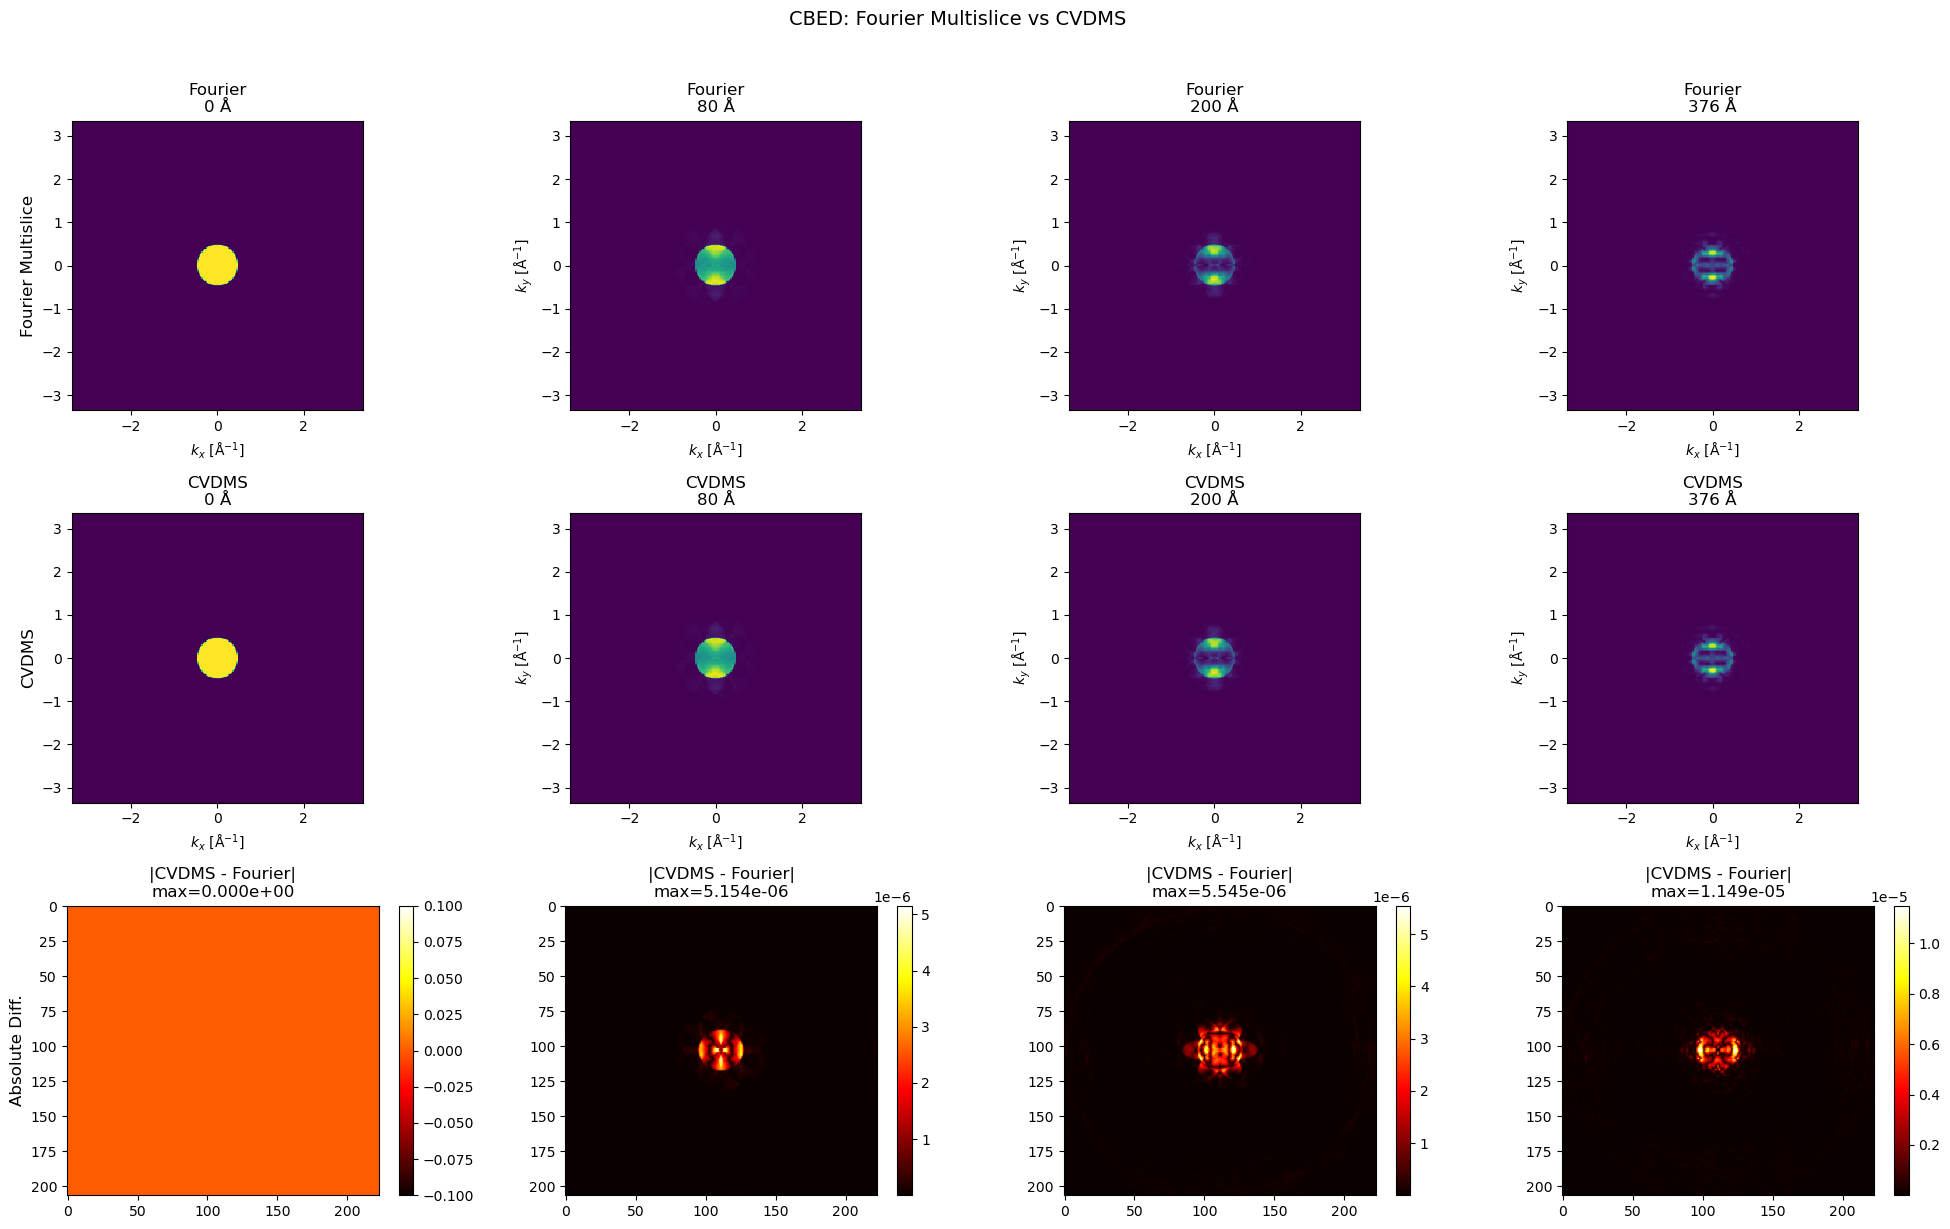

In [7]:
# 选取少数厚度切片进行对比
n_slices = result_fourier.shape[0]
thickness_indices = [0, n_slices // 4, n_slices // 2, n_slices - 1]

# 从坐标轴元数据获取厚度值
try:
    thickness_vals = result_fourier.axes_metadata[0].values
    thickness_labels = [thickness_vals[i] for i in thickness_indices]
except (AttributeError, IndexError, TypeError):
    thickness_labels = [(i + 1) * potential.slice_thickness for i in thickness_indices]

fig, axes = plt.subplots(3, len(thickness_indices), figsize=(5 * len(thickness_indices), 12))

for i, idx in enumerate(thickness_indices):
    # Fourier 结果
    im_f = result_fourier[idx].show(ax=axes[0, i], cmap="viridis")
    axes[0, i].set_title(f"Fourier\n{thickness_labels[i]:.0f} Å")
    
    # CVDMS 结果
    im_c = result_cvdms[idx].show(ax=axes[1, i], cmap="viridis")
    axes[1, i].set_title(f"CVDMS\n{thickness_labels[i]:.0f} Å")
    
    # 绝对差值 — CuPy 计算，.get() 传给 matplotlib
    diff = cp.abs(result_cvdms[idx].array - result_fourier[idx].array)
    im_d = axes[2, i].imshow(diff.get(), cmap="hot", aspect="equal")
    axes[2, i].set_title(f"|CVDMS - Fourier|\nmax={diff.max():.3e}")
    plt.colorbar(im_d, ax=axes[2, i], fraction=0.046)

axes[0, 0].set_ylabel("Fourier Multislice", fontsize=12)
axes[1, 0].set_ylabel("CVDMS", fontsize=12)
axes[2, 0].set_ylabel("Absolute Diff.", fontsize=12)

plt.suptitle("CBED: Fourier Multislice vs CVDMS", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. 线轮廓对比

比较最终厚度处沿中心行的强度轮廓。


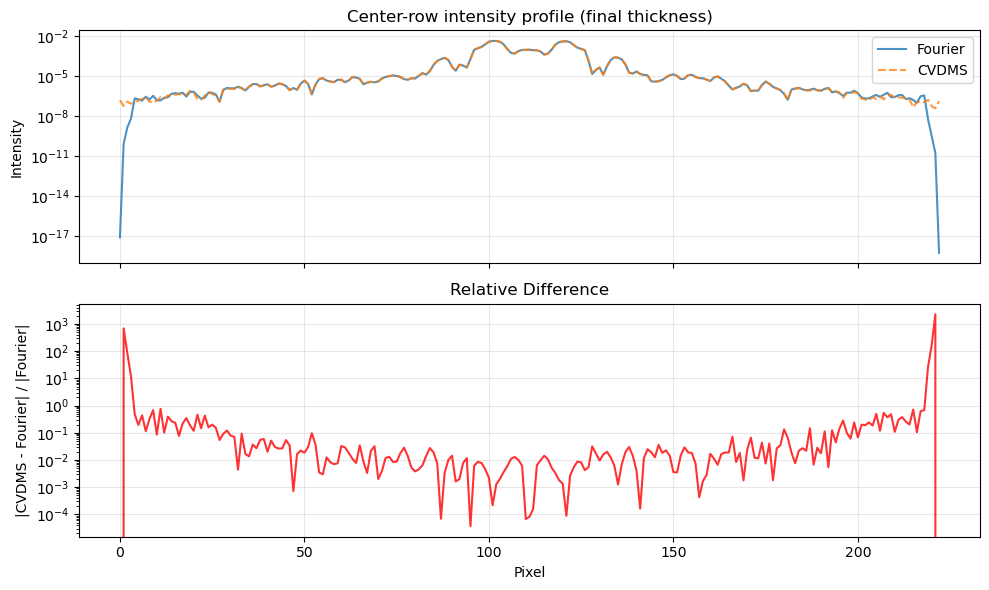

In [8]:
arr_f = result_fourier[-1].array
arr_c = result_cvdms[-1].array

# 中心行轮廓
center_y = arr_f.shape[0] // 2
profile_f = arr_f[center_y, :]
profile_c = arr_c[center_y, :]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

x = np.arange(len(profile_f))
ax1.semilogy(x, cp.abs(profile_f).get(), label="Fourier", alpha=0.8)
ax1.semilogy(x, cp.abs(profile_c).get(), label="CVDMS", alpha=0.8, linestyle="--")
ax1.set_ylabel("Intensity")
ax1.set_title("Center-row intensity profile (final thickness)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 相对差异
with np.errstate(divide="ignore", invalid="ignore"):
    a_f = cp.abs(profile_f)
    a_c = cp.abs(profile_c)
    relative_diff = cp.where(a_f > 1e-15, cp.abs(a_c - a_f) / a_f, 0)
ax2.semilogy(x, relative_diff.get(), color="red", alpha=0.8)
ax2.set_xlabel("Pixel")
ax2.set_ylabel("|CVDMS - Fourier| / |Fourier|")
ax2.set_title("Relative Difference")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 厚度序列对比

跟踪裁剪衍射图总和与花样相似度随厚度的变化。

注意：因 `diffraction_patterns(max_angle="cutoff")` 对衍射图做了角度裁剪，
不同厚度处散射出裁剪角外的电子量不同，因此曲线不代表总电子通量守恒。
此处仅展示两个算法的相对趋势。


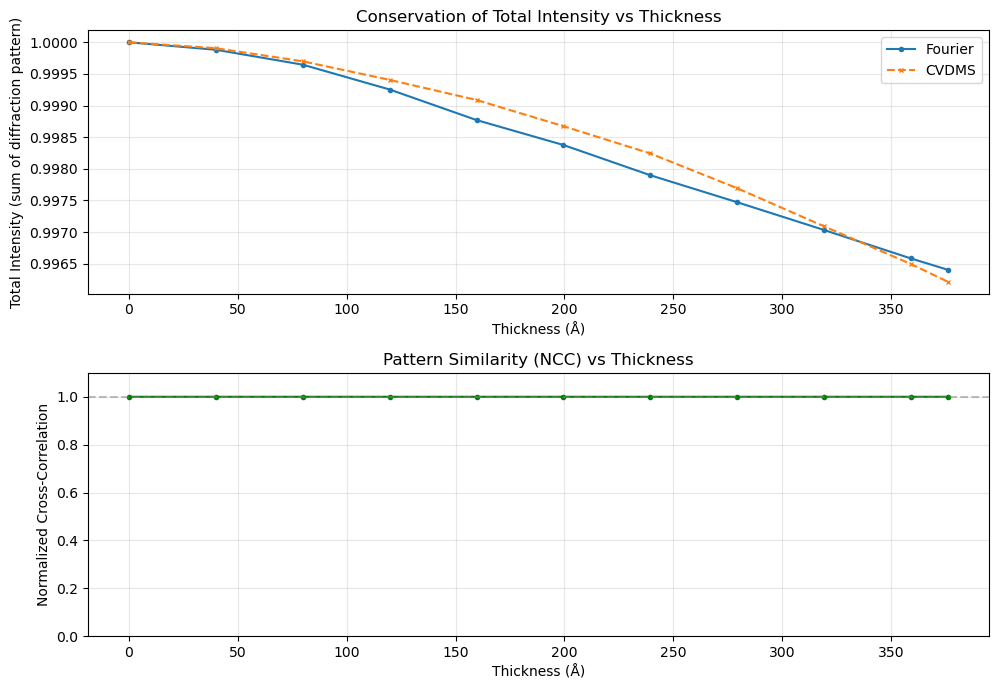

Intensity conservation — Fourier: max |ΔI/I₀| = 4.8327e-04
Intensity conservation — CVDMS: max |ΔI/I₀| = 6.0242e-04
Mean NCC across all thicknesses: 0.999998
Min NCC: 0.999995 at thickness 359 Å


In [9]:
# 从坐标轴元数据获取厚度值
try:
    thickness_vals = np.array(result_fourier.axes_metadata[0].values)
except (AttributeError, IndexError, TypeError):
    thickness_vals = np.arange(1, n_slices + 1) * potential.slice_thickness

# 裁剪衍射图的总和（非总电子通量）
# result_fourier/result_cvdms 使用 max_angle="cutoff"，
# 因此 array.sum() 仅统计裁剪孔径内的强度。
# 由于不同厚度处散射到裁剪角外的电子量不同，
# 该值会随厚度自然衰减，不代表 Parseval 守恒。
total_int_f = np.array([float(result_fourier[i].array.sum()) for i in range(n_slices)])
total_int_c = np.array([float(result_cvdms[i].array.sum()) for i in range(n_slices)])

# 每层厚度切片的归一化互相关 — 强度花样相似度
ncc = []
for i in range(n_slices):
    a = result_fourier[i].array.ravel()
    b = result_cvdms[i].array.ravel()
    a -= a.mean()
    b -= b.mean()
    denom = cp.sqrt((a**2).sum() * (b**2).sum())
    ncc.append(float(cp.dot(a, b) / denom) if denom > 0 else 1.0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

ax1.plot(thickness_vals, total_int_f, "o-", markersize=3, label="Fourier")
ax1.plot(thickness_vals, total_int_c, "x--", markersize=3, label="CVDMS")
ax1.set_xlabel("Thickness (Å)")
ax1.set_ylabel("Sum of Cropped Diffraction Pattern")
ax1.set_title("Cropped Diffraction Intensity vs Thickness")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(thickness_vals, ncc, "o-", markersize=3, color="green")
ax2.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="NCC = 1")
ax2.set_xlabel("Thickness (Å)")
ax2.set_ylabel("Normalized Cross-Correlation")
ax2.set_title("Pattern Similarity (NCC) vs Thickness")
ax2.set_ylim(0, 1.1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Fourier cropped sum: max |ΔI/I₀| = {np.max(np.abs(np.diff(total_int_f)) / total_int_f[0]):.4e}")
print(f"CVDMS cropped sum:  max |ΔI/I₀| = {np.max(np.abs(np.diff(total_int_c)) / total_int_c[0]):.4e}")
print(f"Mean NCC across all thicknesses: {np.mean(ncc):.6f}")
print(f"Min NCC: {np.min(ncc):.6f} at thickness {thickness_vals[np.argmin(ncc)]:.0f} Å")


## 6. 背散射效应对比

比较无背散射的 CVDMS (FD) 与带 BSC 前向波修正的 CVDMS (BSC, `backscattering=True`)，观察背散射修正对前向波的影响。

注意：此对比展示了在每个切片界面扣除背散射损失对前向波的校正效果。完整的背散射波反向传播分析需要同时设置 `backscattering=True` 和 `calculate_backscattered=True`。

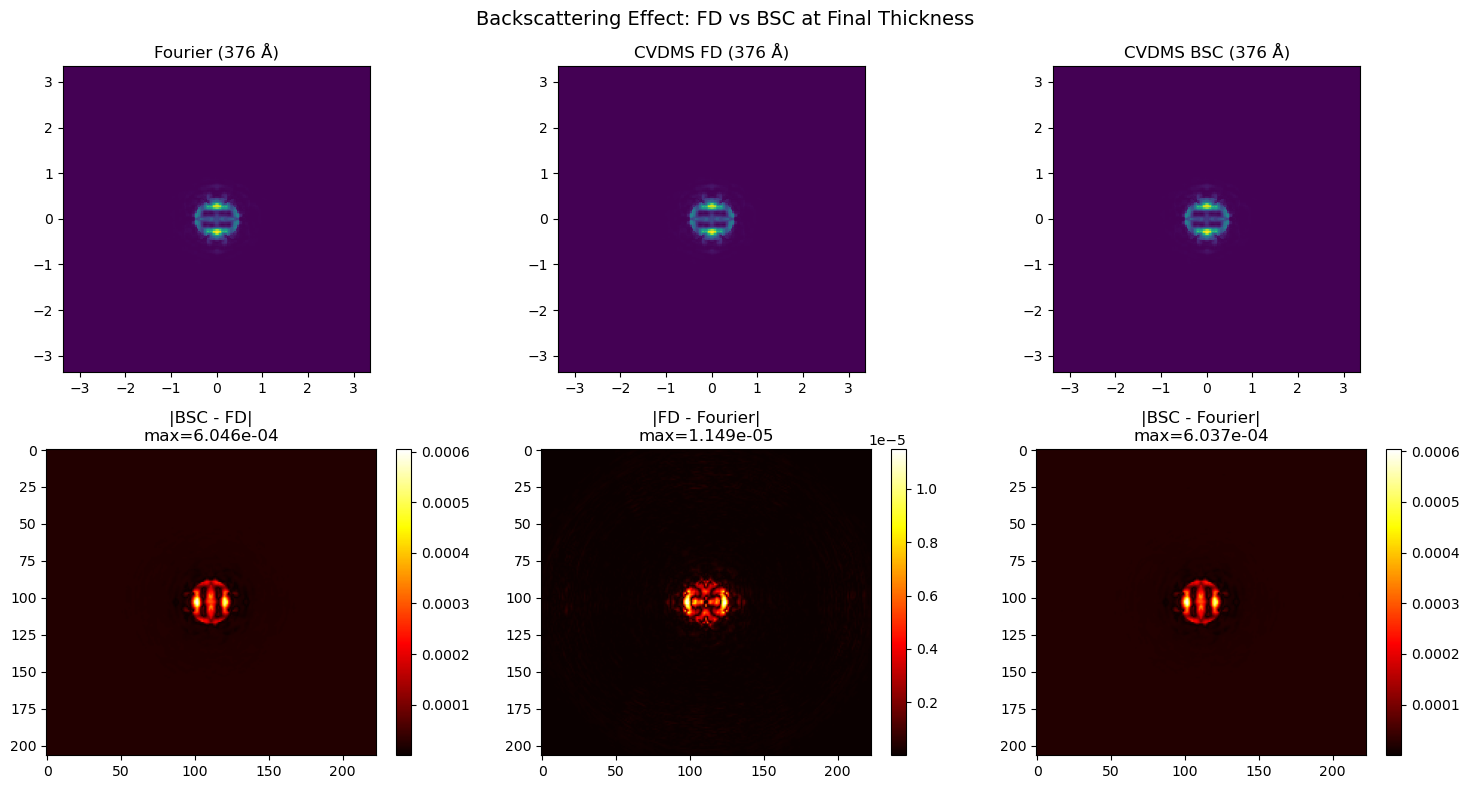

In [10]:
# 在最终厚度处比较 FD 与 BSC
n_slices = result_fourier.shape[0]
last_idx = n_slices - 1

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 尝试获取厚度标签
try:
    thickness_vals = result_fourier.axes_metadata[0].values
    t_label = f"{thickness_vals[last_idx]:.0f} Å"
except Exception:
    t_label = f"slice {last_idx}"

# Fourier 结果
result_fourier[last_idx].show(ax=axes[0, 0], cmap="viridis")
axes[0, 0].set_title(f"Fourier ({t_label})")

# CVDMS FD
result_cvdms_fd[last_idx].show(ax=axes[0, 1], cmap="viridis")
axes[0, 1].set_title(f"CVDMS FD ({t_label})")

# CVDMS BSC
result_cvdms_bsc[last_idx].show(ax=axes[0, 2], cmap="viridis")
axes[0, 2].set_title(f"CVDMS BSC ({t_label})")

# 差值：BSC vs FD
diff_bsc_fd = cp.abs(result_cvdms_bsc[last_idx].array - result_cvdms_fd[last_idx].array)
im1 = axes[1, 0].imshow(diff_bsc_fd.get(), cmap="hot", aspect="equal")
axes[1, 0].set_title(f"|BSC - FD|\nmax={diff_bsc_fd.max():.3e}")
plt.colorbar(im1, ax=axes[1, 0], fraction=0.046)

# 差值：FD vs Fourier
diff_fd_f = cp.abs(result_cvdms_fd[last_idx].array - result_fourier[last_idx].array)
im2 = axes[1, 1].imshow(diff_fd_f.get(), cmap="hot", aspect="equal")
axes[1, 1].set_title(f"|FD - Fourier|\nmax={diff_fd_f.max():.3e}")
plt.colorbar(im2, ax=axes[1, 1], fraction=0.046)

# 差值：BSC vs Fourier
diff_bsc_f = cp.abs(result_cvdms_bsc[last_idx].array - result_fourier[last_idx].array)
im3 = axes[1, 2].imshow(diff_bsc_f.get(), cmap="hot", aspect="equal")
axes[1, 2].set_title(f"|BSC - Fourier|\nmax={diff_bsc_f.max():.3e}")
plt.colorbar(im3, ax=axes[1, 2], fraction=0.046)

for ax in axes[0]:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Backscattering Effect: FD vs BSC at Final Thickness", fontsize=14)
plt.tight_layout()
plt.show()

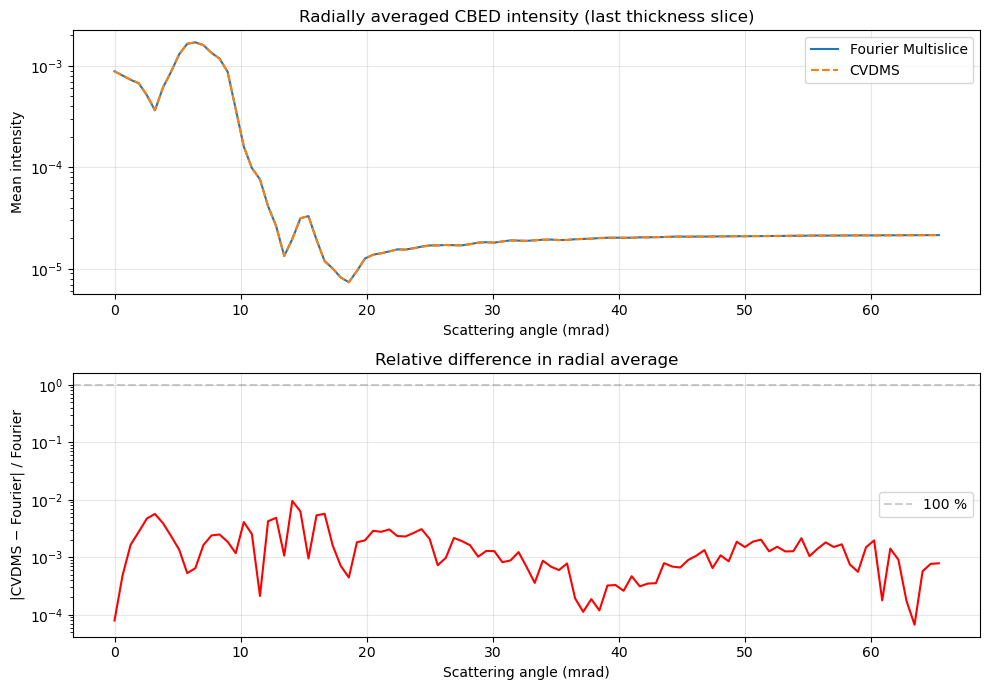

Mean relative diff (radial): 1.6222e-03
Max  relative diff (radial): 9.5474e-03


In [11]:
# Radial (azimuthal) average comparison between Fourier and CVDMS
def radial_profile(arr, center=None):
    """Compute radially averaged intensity of a 2D diffraction pattern.

    Parameters
    ----------
    arr : cp.ndarray or np.ndarray
        2D array (CuPy or NumPy).
    center : tuple, optional
        (cy, cx) center coordinates. Defaults to array center.

    Returns
    -------
    np.ndarray
        Radially averaged intensity profile.
    """
    h, w = arr.shape
    if center is None:
        center = (h // 2, w // 2)

    # 计算半径映射（使用 NumPy meshgrid，开销低）
    y, x = np.ogrid[:h, :w]
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2).astype(int)

    # CuPy → NumPy 一次转换，后续全部 NumPy 操作
    data = np.abs(arr.get() if hasattr(arr, 'get') else arr)

    # 通过 bincount 进行径向分箱（向量化，无循环）
    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())
    return tbin / np.maximum(nr, 1)


# ---- 计算角度刻度 (mrad/pixel) ----
# 尝试多种方法获取衍射图每像素对应角度 (mrad)。
angle_scale, angle_offset, angle_label = None, 0.0, "Radial distance (pixels)"

# 方法1：从结果坐标轴元数据
#   ReciprocalSpaceAxis uses .sampling (not .scale) for mrad/pixel
try:
    ax = result_fourier.axes_metadata[-1]
    if hasattr(ax, 'sampling') and ax.sampling is not None and abs(ax.sampling) > 1e-12:
        if 'mrad' in str(getattr(ax, 'units', '')):
            angle_scale = float(ax.sampling)
            angle_offset = float(getattr(ax, 'offset', 0))
            angle_label = "Scattering angle (mrad)"
except Exception:
    pass

# 方法2：从波函数网格计算
if angle_scale is None:
    try:
        from abtem.core.energy import energy2wavelength
        lam = energy2wavelength(getattr(wave, 'energy', 300e3))  # Å
        gpts = getattr(wave, 'gpts', None)
        if gpts is None:
            gpts = getattr(wave.grid, 'gpts', None)
        sampling = getattr(wave, 'sampling', None)
        if sampling is None:
            sampling = getattr(wave.grid, 'sampling', None)
        if gpts is not None and sampling is not None:
            nx = gpts[0] if hasattr(gpts, '__iter__') else gpts
            dx = sampling[0] if hasattr(sampling, '__iter__') else sampling
            # λ / (N × d)  rad/pixel → mrad/pixel
            angle_scale = float(lam / (nx * dx) * 1000)
            angle_offset = 0.0
            angle_label = "Scattering angle (mrad)"
    except Exception:
        pass

# 方法3：从势能计算
if angle_scale is None:
    try:
        from abtem.core.energy import energy2wavelength
        lam = energy2wavelength(300e3)  # Å
        gpts = potential.gpts
        samp = potential.sampling
        nx = gpts[0] if hasattr(gpts, '__iter__') else gpts
        dx = samp[0] if hasattr(sampling, '__iter__') else samp
        angle_scale = float(lam / (nx * dx) * 1000)
        angle_offset = 0.0
        angle_label = "Scattering angle (mrad)"
    except Exception:
        pass


# ---- 计算径向轮廓 ----
arr_f = result_fourier[-1].array
arr_c = result_cvdms[-1].array

radial_f = radial_profile(arr_f)
radial_c = radial_profile(arr_c)

# 只显示到有效半尺寸
max_r = min(len(radial_f), len(radial_c), min(arr_f.shape) // 2)

# 角度 x 轴
if angle_scale is not None:
    angles = np.arange(max_r) * angle_scale + angle_offset
else:
    angles = np.arange(max_r)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

ax1.semilogy(angles, radial_f[:max_r], label="Fourier Multislice")
ax1.semilogy(angles, radial_c[:max_r], label="CVDMS", linestyle="--")
ax1.set_xlabel(angle_label)
ax1.set_ylabel("Mean intensity")
ax1.set_title("Radially averaged CBED intensity (last thickness slice)")
ax1.legend()
ax1.grid(True, alpha=0.3)

with np.errstate(divide="ignore", invalid="ignore"):
    rel_diff = np.abs(radial_c - radial_f) / np.maximum(radial_f, 1e-15)
ax2.semilogy(angles, rel_diff[:max_r], color="red")
ax2.axhline(y=1.0, color="gray", linestyle="--", alpha=0.4, label="100 %")
ax2.set_xlabel(angle_label)
ax2.set_ylabel("|CVDMS − Fourier| / Fourier")
ax2.set_title("Relative difference in radial average")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean relative diff (radial): {np.nanmean(rel_diff[:max_r]):.4e}")
print(f"Max  relative diff (radial): {np.nanmax(rel_diff[:max_r]):.4e}")

## 总结

| 方面 | Fourier 多片层 | CVDMS |
|------|---------------|-------|
| 算法 | 传统分步传播 | 耦合波动学多片层 |
| 前向波背散射修正 | 忽略 | 每个界面 BSC 扣除 (`backscattering=True`) |
| 背散射波反向传播 | 无 | 额外输出 (`calculate_backscattered=True`) |
| 收敛控制 | 固定阶数 | 自适应双层 Taylor 级数（外层+内层），逐像素收敛 |
| Laplacian | FFT 传播 | 有限差分（默认 9 点，`derivative_accuracy=8`）或 FFT（`laplace_method="fft"`） |
| GPU 支持 | 是 (CuPy) | 是 (CuPy, via `get_array_module`) |

CVDMS 算法在每个切片界面对前向波做背散射修正。通过 `CVDMSMultislice(backscattering=True)` 启用。当 `backscattering=True` 时，前向波被修正为 `ψ_corrected = ψ_forward - BSC(ψ_forward)`。

`backscattering` 参数仅控制前向波是否被修正。如需额外累积背散射分量并反向传播为独立输出，需同时设置 `backscattering=True` 和 `calculate_backscattered=True`。

Laplacian 算子有两种方法：
- **finite-difference**（默认）：9 点模板（`derivative_accuracy=8`），对应 C++ "九点法"
- **fft**：基于 FFT 的精确带限 Laplacian，对应原始 CUDA 代码中的 `MultiCoefInReciprocalSpace`

## 7. 强度守恒检验

### 为什么要做这个测试

对于弹性散射，**Parseval 定理**要求出口波函数的模方守恒：

\[
\sum |\psi(z_1)|^2 = \sum |\psi(z_2)|^2 \quad \text{（在理想幺正传播下）}
\]

物理意义：电子在样品中既不会产生也不会消失——它们只是在角度上被重新分布。
一个理想幺正的多片层实现应在每个出口面满足这一不变性。

### 为何 Fourier 多片层也不精确守恒

abTEM 的 Fourier 多片层为了数值稳定性，在传播器和透射函数上都施加了
**抗混叠低通滤波器**（2/3 Nyquist 处截止，余弦渐变）：

- **传播器**：`P × A`，其中 `A` 是实值孔径（`A < 1`），高频分量被衰减
- **透射函数**：`bandlimit(exp(i·σ·V))` 低通滤波后不再是纯相位

因此 `sum(|ψ|²)` 会逐层略有衰减，非严格幺正。这是数值稳定性与精确守恒之间的
折中。我们的目标是确保 **CVDMS 相比 Fourier 基线没有额外显著退化**。

### 为什么不直接在衍射图上做检验

本 notebook 早期使用 `diffraction_patterns(max_angle="cutoff")` **裁剪后**的衍射图做跨面对比。
但裁剪后的总和并不守恒——不同厚度处散射到裁剪角外的电子数量不同，
因此裁剪区域内的总和也随厚度变化。
正确的检验应在完整出口波函数上做 `sum(|ψ|²)`。

### 此测试发现的历史 bug

本 notebook 最初将总强度计算为 `sum(|array|²)`。
然而，`diffraction_patterns()` 已经返回 `|FFT(ψ)|²`（强度）。
二次平方产生了物理上无意义的值。


In [ ]:
print("Running intensity conservation checks...")

# 使用单配置势能（无冻声子）单独做守恒检验，避免裁剪带来的假象。
# 对完整出口波函数做 sum(|psi|²)。
# 注意：abTEM 的 Fourier 多片层因抗混叠低通滤波器非严格幺正，
#       预期会有微小衰减。测试采用相对比较策略：
#       CVDMS 的退化不应超过 Fourier 基线的 10 倍。
potential_single = abtem.Potential(
    atoms,
    sampling=0.05,
    gpts=potential.gpts,
    projection="finite",
    slice_thickness=1,
    exit_planes=40,
)

# --- Fourier 基线的非幺正性 ---
print("Computing Fourier conservation...")
exit_f = wave.multislice(potential_single, algorithm=FourierMultislice(order=1))
exit_f = exit_f.compute()
arr_f = np.asarray(exit_f.array.get()) if hasattr(exit_f.array, "get") else np.asarray(exit_f.array)
totals_f = [float(np.sum(np.abs(arr_f[i])**2)) for i in range(arr_f.shape[0])]
max_rel_diff_f = max(abs(t - totals_f[0]) / totals_f[0] for t in totals_f)
print(f"Fourier multislice: max |ΔI|/I₀ = {max_rel_diff_f:.4e}")

# --- CVDMS 额外退化 ---
print("Computing CVDMS conservation...")
exit_c = wave.multislice(potential_single, algorithm=CVDMSMultislice(order=1))
exit_c = exit_c.compute()
arr_c = np.asarray(exit_c.array.get()) if hasattr(exit_c.array, "get") else np.asarray(exit_c.array)
totals_c = [float(np.sum(np.abs(arr_c[i])**2)) for i in range(arr_c.shape[0])]
max_rel_diff_c = max(abs(t - totals_c[0]) / totals_c[0] for t in totals_c)
print(f"CVDMS multislice:  max |ΔI|/I₀ = {max_rel_diff_c:.4e}")

# CVDMS 不应比 Fourier 基线退化超过 10 倍
ratio = max_rel_diff_c / max(max_rel_diff_f, 1e-30)
print(f"CVDMS / Fourier ratio = {ratio:.1f}x")
assert ratio < 10, f"CVDMS conservation degradation too large: {ratio:.1f}x Fourier!"
print("  ✓ CVDMS conservation is within acceptable range relative to Fourier\n")
print("All intensity conservation checks passed.")


Running intensity conservation checks...
Computing Fourier conservation...


/media/chenguisen/WD_BLACK/cgs/cgs/program/multem_cgs/abTEM/abtem/core/grid.py:142: UserWarning: Overspecified grid, the provided sampling is ignored
  warnings.warn("Overspecified grid, the provided sampling is ignored")


tasks:   0%|          | 0/6 [00:00<?, ?it/s]

Fourier multislice: max |ΔI|/I₀ = 7.9563e-03
Computing CVDMS conservation...


tasks:   0%|          | 0/6 [00:00<?, ?it/s]

CVDMS multislice:  max |ΔI|/I₀ = 5.8971e-03
CVDMS / Fourier ratio = 0.7x
  ✓ CVDMS conservation is within acceptable range relative to Fourier

All intensity conservation checks passed.
